<a href="https://colab.research.google.com/github/NatalieAleksandrova2026/DTA_2026/blob/main/Statistics/practice_stat_tests_HARDER_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Статистичні тести: поглиблений практикум

**Рівень:** середній+ · фокус на **інтерпретації** · бібліотека `scipy.stats`

---

Цей практикум складніший за попередній. Тут менше «механічного» застосування тестів і більше **роздумів**: ви будете обирати тести самостійно, помічати пастки і — найголовніше — **пояснювати, що результат означає для бізнесу**.

### Що нового порівняно з минулим практикумом
- 🧠 Більшість завдань вимагають, щоб ви **самі обрали тест** і обґрунтували вибір.
- 🪤 Тут є **пастки**: випадки, де p < 0.05, але результат практично не важливий; де дані спотворені викидами; де результат «на межі».
- 💬 На кожне завдання — **розгорнута інтерпретація**. Саме це відрізняє аналітика від калькулятора.

### Як працювати
1. До кожного завдання є **підказки** — користуйтесь ними, але спершу подумайте самі.
2. Інтерпретації пишіть так, ніби пояснюєте керівнику **без** статистичної освіти.
3. Не зупиняйтесь на «p < 0.05, значущо» — завжди питайте: *наскільки великий ефект? чи це важливо на практиці? чи можна довіряти даним?*

> ⚠️ Головна теза практикуму: **статистична значущість ≠ практична важливість.** Тримайте це в голові протягом усієї роботи.

---

## Підготовка

Працюємо з даними SaaS-продукту (онлайн-сервіс за підпискою). Запустіть клітинку нижче.

**`saas_users.csv`** — 1200 користувачів:

| Стовпець | Опис | Тип |
|---|---|---|
| `user_id` | ID користувача | — |
| `plan` | Тариф (Free / Pro / Business) | категоріальний |
| `region` | Регіон (Europe / Americas / Asia) | категоріальний |
| `signup_source` | Джерело реєстрації (Search / Referral / Ads / Social) | категоріальний |
| `support_tickets` | Кількість звернень у підтримку | числовий |
| `weekly_sessions` | Сеансів на тиждень | числовий |
| `feature_adopted` | Чи почав користуватись новою функцією (Так/Ні) | категоріальний |
| `nps_before` | Оцінка лояльності NPS ДО оновлення (0-10) | числовий |
| `nps_after` | NPS ПІСЛЯ оновлення (0-10) | числовий |

**`onboarding_ab.csv`** — A/B-тест нового онбордингу (100 000 користувачів!):

| Стовпець | Опис |
|---|---|
| `user_id` | ID |
| `variant` | Control (старий онбординг) або Treatment (новий) |
| `signed_up` | Чи завершив реєстрацію (1/0) |


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

users = pd.read_csv("saas_users.csv")
ab = pd.read_csv("onboarding_ab.csv")

print("Користувачі:", users.shape)
print("A/B онбординг:", ab.shape)
users.head()

Користувачі: (1200, 9)
A/B онбординг: (100000, 3)


,user_id,plan,region,signup_source,support_tickets,weekly_sessions,feature_adopted,nps_before,nps_after
0,10001,Free,Americas,Social,2,11,Так,5,3
1,10002,Pro,Asia,Search,12,16,Ні,6,3
2,10003,Free,Asia,Social,6,11,Ні,5,5
3,10004,Business,Americas,Referral,4,27,Ні,7,7
4,10005,Pro,Asia,Referral,1,8,Ні,4,6


---
# Розділ 1. Спочатку — подивись на дані уважно

## 🟦 Чому це важливо
Перш ніж застосовувати тести, аналітик завжди вивчає дані. Тести роблять припущення (наприклад, t-тест найкраще працює, коли дані приблизно симетричні). Якщо дані сильно спотворені викидами — середнє може вводити в оману, і висновок тесту теж.

#### ✏️ Завдання 1 (код)

Виведіть описову статистику (`.describe()`) для числових стовпців. Окремо порівняйте **середнє** і **медіану** стовпця `support_tickets`.

> 💡 **Підказка:** Для медіани: `users['support_tickets'].median()`. Зверніть увагу, чи сильно середнє відрізняється від медіани.

In [2]:
# Завдання 1:
print(users.describe())

print(f"\nsupport_tickets:")
print(f"  Mean:   {users['support_tickets'].mean():.2f}")
print(f"  Median: {users['support_tickets'].median():.2f}")

diff = users['support_tickets'].mean() - users['support_tickets'].median()
print(f"  Difference: {diff:.2f}")

if abs(diff) > 0.5:
    print("  ⚠️ Mean and median differ significantly → possible outliers or skewed distribution")
else:
    print("  ✅ Mean and median are close → distribution is fairly symmetric")

            user_id  support_tickets  weekly_sessions   nps_before  \
count   1200.000000      1200.000000      1200.000000  1200.000000   
mean   10600.500000         2.105000        11.500833     6.930000   
std      346.554469         2.606333         6.395109     1.916114   
min    10001.000000         0.000000         1.000000     1.000000   
25%    10300.750000         0.000000         7.000000     6.000000   
50%    10600.500000         1.000000        11.000000     7.000000   
75%    10900.250000         3.000000        16.000000     8.000000   
max    11200.000000        20.000000        38.000000    10.000000   

         nps_after  
count  1200.000000  
mean      7.149167  
std       2.200216  
min       0.000000  
25%       6.000000  
50%       7.000000  
75%       9.000000  
max      10.000000  

support_tickets:
  Mean:   2.10
  Median: 1.00
  Difference: 1.10
  ⚠️ Mean and median differ significantly → possible outliers or skewed distribution


#### 💬 Інтерпретація 1

Порівняйте середнє і медіану `support_tickets`. Що це говорить про форму розподілу (чи є викиди — користувачі з дуже великою кількістю звернень)? Чому для такого стовпця варто бути обережним із t-тестом?

> 🧭 **Орієнтир для відповіді:** Якщо середнє помітно більше за медіану — розподіл «витягнутий» вправо (є кілька користувачів з дуже багатьма зверненнями). Подумайте, як викиди впливають на середнє.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Mean:   2.10
Median: 1.00
Difference: 1.10

What this tells us about the distribution:
Mean > Median → the distribution is RIGHT-SKEWED.
This means most users have 0-1 support tickets,
but a small number of users have many tickets (up to 20),
pulling the mean upward.

Are there outliers?
Yes — max = 20 tickets while 75% of users have 3 or fewer.
These heavy users significantly inflate the mean.  
Why be careful with t-test for this column:
The t-test assumes that the data is approximately normally distributed.
A right-skewed distribution with outliers violates this assumption.

In such cases:
- The mean is not a good representation of the "typical" user
- The t-test result may be unreliable
- Better alternatives: Mann-Whitney U test (non-parametric)
  which uses median ranks instead of means
  and is robust to outliers and skewed distributions

#### ✏️ Завдання 2 (код)

Побудуйте гістограму `support_tickets`, щоб побачити розподіл на власні очі.

> 💡 **Підказка:** `users['support_tickets'].plot(kind='hist', bins=20)` і потім `plt.show()`.

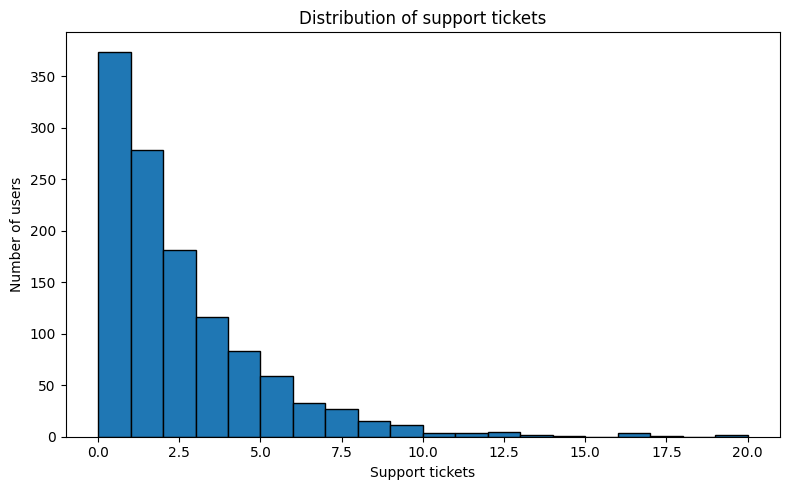

In [3]:
# Завдання 2:
plt.figure(figsize=(8, 5))
users['support_tickets'].plot(kind='hist', bins=20, edgecolor='black')
plt.xlabel("Support tickets")
plt.ylabel("Number of users")
plt.title("Distribution of support tickets")
plt.tight_layout()
plt.show()

#### 💬 Інтерпретація 2

Що видно на гістограмі? Підтверджує вона ваш висновок про викиди з попереднього завдання?

> 🧭 **Орієнтир для відповіді:** Опишіть форму: чи більшість значень малі, а «хвіст» тягнеться до великих? Це типовий скошений (skewed) розподіл.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

What the histogram shows:

The distribution is clearly RIGHT-SKEWED:
- The tallest bar is at 0-1 tickets (~370 users)
- Bars drop sharply moving right
- A long tail stretches all the way to 20 tickets
- Very few users have more than 10 tickets

This confirms our previous conclusion:
The majority of users rarely contact support (0-2 tickets),
but a small group of users with 15-20 tickets
pulls the mean up from 1.0 (median) to 2.10 (mean).

Yes — the histogram fully confirms the outlier conclusion.
This is a classic skewed distribution.
The t-test should be used with caution here.

---
# Розділ 2. Порівняння кількох груп — обери тест сам

## 🟦 Нагадування
Коли треба порівняти числову величину між **3+ групами**, згадайте, який тест підходить. Не забувайте: він каже лише, що різниця *десь є*, але не каже, *між якими саме* групами.

#### ✏️ Завдання 3 (код)

Користувачі різних тарифів (`plan`) можуть по-різному користуватись продуктом. Перевірте, чи відрізняється середня кількість сеансів на тиждень (`weekly_sessions`) між тарифами Free / Pro / Business. Спершу виведіть середні по групах, потім проведіть відповідний тест.

> 💡 **Підказка:** Три групи + числова змінна → ANOVA (`stats.f_oneway`). Зберіть групи у список: `[users[users.plan==p].weekly_sessions for p in users.plan.unique()]`.

In [4]:
# Завдання 3:
for plan in users["plan"].unique():
    avg = users[users["plan"] == plan]["weekly_sessions"].mean()
    print(f"{plan}: {avg:.2f} sessions/week")

groups = [users[users["plan"] == p]["weekly_sessions"] for p in users["plan"].unique()]

f_stat, p_value = stats.f_oneway(*groups)
print(f"\nF-statistic: {f_stat:.3f}")
print(f"p-value:     {p_value:.4f}")

if p_value < 0.05:
    print("✅ At least one plan differs significantly in weekly sessions")
else:
    print("❌ No significant difference between plans")

Free: 7.93 sessions/week
Pro: 13.30 sessions/week
Business: 19.59 sessions/week

F-statistic: 415.194
p-value:     0.0000
✅ At least one plan differs significantly in weekly sessions


#### 💬 Інтерпретація 3

Чи відрізняються тарифи за активністю? Який тариф найактивніший? І ключове питання: чому за результатом ANOVA ви НЕ можете одразу стверджувати, що, наприклад, Pro значущо активніший за Free? Що для цього треба було б зробити додатково?

> 🧭 **Орієнтир для відповіді:** ANOVA виявляє різницю «хоча б десь». Для конкретних пар потрібні post-hoc тести (напр. Тьюкі) або попарні порівняння з поправкою на множинність.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Free: 7.93, Pro: 13.30, Business: 19.59 sessions/week
F-statistic = 415.194, p ≈ 0.0000 (< 0.05) → we reject H₀.

Yes, plans differ significantly in activity.
Business plan users are the most active (19.59 sessions/week),
followed by Pro (13.30) and Free (7.93).

Why we CANNOT say Pro is significantly more active than Free:
ANOVA only answers ONE question:
"Is there at least one difference somewhere among the three groups?"
It does NOT tell us WHICH specific pairs differ.

In theory it is possible that:
- Business differs from both Free and Pro ✅
- But Pro and Free are actually similar ❓  
To compare specific pairs we need POST-HOC TESTS:
- Tukey HSD — most common, compares all pairs simultaneously
- Bonferroni correction — adjusts p-value for multiple comparisons

Without post-hoc tests any statement like
"Pro is significantly better than Free" is statistically unjustified,
even if the numbers look different.

In our case the differences look large (7.93 vs 13.30 vs 19.59),
so post-hoc tests would likely confirm all three pairs differ —
but we must verify this statistically, not just visually.

#### ✏️ Завдання 4 (код)

Тепер перевірте, чи відрізняється `weekly_sessions` між регіонами (`region`).

> 💡 **Підказка:** Той самий тест, що й вище, але групуєте за `region`.

In [5]:
# Завдання 4:
for region in users["region"].unique():
    avg = users[users["region"] == region]["weekly_sessions"].mean()
    print(f"{region}: {avg:.2f} sessions/week")

# ANOVA
groups = [users[users["region"] == r]["weekly_sessions"] for r in users["region"].unique()]

f_stat, p_value = stats.f_oneway(*groups)
print(f"\nF-statistic: {f_stat:.3f}")
print(f"p-value:     {p_value:.4f}")

if p_value < 0.05:
    print("✅ At least one region differs significantly in weekly sessions")
else:
    print("❌ No significant difference between regions")

Americas: 10.78 sessions/week
Asia: 11.52 sessions/week
Europe: 12.28 sessions/week

F-statistic: 5.546
p-value:     0.0040
✅ At least one region differs significantly in weekly sessions


#### 💬 Інтерпретація 4

Порівняйте цей результат із попереднім (тарифи). В одному випадку різниця значуща, в іншому — ні (або слабша). Що це означає для продукту: який фактор (тариф чи регіон) сильніше пов'язаний з активністю користувача?

> 🧭 **Орієнтир для відповіді:** Зверніть увагу не лише на сам факт значущості, а й на те, наскільки далекі середні між групами одне від одного.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

BY PLAN:
Free: 7.93 | Pro: 13.30 | Business: 19.59
F = 415.194, p ≈ 0.0000
Difference between groups: 11.66 sessions (7.93 to 19.59)

BY REGION:
Americas: 10.78 | Asia: 11.52 | Europe: 12.28
F = 5.546, p = 0.004
Difference between groups: 1.50 sessions (10.78 to 12.28)

Both results are statistically significant (p < 0.05).
However the PRACTICAL difference is very different:  
PLAN is a much stronger factor:
- F-statistic 415 vs 5.5 — plan explains far more variation
- The gap between Free and Business is 11.66 sessions
- This is a huge real-world difference

REGION is a weak factor:
- Yes, p = 0.004 is significant
- But the gap between Americas and Europe is only 1.50 sessions
- With 1200 users even tiny differences become statistically significant
- Practically this difference is negligible

Conclusion for the product team:
PLAN is the dominant factor driving user activity.
Region plays a minimal role.
Focus product development and engagement strategies
on plan-based segmentation, not regional differences.
Upgrading users from Free to Pro or Business
will have a much greater impact on activity
than any region-specific initiative.

---
# Розділ 3. До і після — і розмір ефекту

## 🟦 Новий акцент: розмір ефекту
Тут ви зустрінете важливу пастку. Тест може показати «значущо» (p < 0.05), але **величина зміни** може бути крихітною. Аналітик завжди дивиться на обидві речі: і p-значення, і **наскільки великий** ефект.

#### ✏️ Завдання 5 (код)

Компанія оновила онбординг і виміряла NPS (лояльність) тих самих користувачів до (`nps_before`) і після (`nps_after`). Проведіть відповідний тест. Додатково порахуйте **середню зміну** NPS (різницю after − before).

> 💡 **Підказка:** Ті самі користувачі двічі → парний t-тест (`stats.ttest_rel`). Середня зміна: `(users['nps_after'] - users['nps_before']).mean()`.

In [6]:
# Завдання 5:
print(f"NPS before: {users['nps_before'].mean():.3f}")
print(f"NPS after:  {users['nps_after'].mean():.3f}")

# Середня зміна
mean_change = (users['nps_after'] - users['nps_before']).mean()
print(f"Average change: {mean_change:.3f}")

# Парний t-тест
t_stat, p_value = stats.ttest_rel(users['nps_before'], users['nps_after'])
print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value:.4f}")

if p_value < 0.05:
    print("✅ Significant change in NPS after onboarding update")
else:
    print("❌ No significant change found")


NPS before: 6.930
NPS after:  7.149
Average change: 0.219

t-statistic: -5.499
p-value:     0.0000
✅ Significant change in NPS after onboarding update


#### 💬 Інтерпретація 5

Тут — важлива пастка. Подивіться на p-значення І на розмір зміни. Чи зміна статистично значуща? А наскільки вона велика в балах NPS? Чи варто компанії святкувати «значуще покращення», якщо середній NPS зріс лише на ~0.2 бала з 10? Сформулюйте збалансований висновок.

> 🧭 **Орієнтир для відповіді:** Розрізняйте «статистично значущо» (різниця не випадкова) і «практично важливо» (різниця достатньо велика, щоб мати сенс для бізнесу). Тут перше — так, а друге — під питанням.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

NPS before: 6.930 | NPS after: 7.149
Average change: +0.219 points
t-statistic = -5.499, p ≈ 0.0000 → statistically significant.

STATISTICALLY: YES — the change is significant.
p is virtually zero, the result is not random.
With 1200 users even tiny differences become detectable.

PRACTICALLY: QUESTIONABLE.
+0.219 points on a 10-point scale is a very small change.
That is roughly 2% improvement.
Most customers would not even notice this difference.  
The trap here:
Large sample size (1200 users) gives the test enormous power —
it can detect even meaningless tiny differences as "significant".
This is why p-value alone is never enough.

Balanced conclusion:
The onboarding update produced a statistically significant
but practically modest improvement in NPS (+0.22 points).
The company should NOT celebrate this as a major win.

Before investing further in this direction, consider:
- Is +0.22 NPS points enough to impact customer retention?
- What was the cost of the onboarding redesign?
- Would that budget be better spent elsewhere?
Recommendation: treat this as a small positive signal,
not a breakthrough. Look for initiatives that move
NPS by 1+ points to achieve meaningful business impact.

---
# Розділ 4. 🪤 Велика пастка: A/B-тест на 100 000 користувачів

## 🟦 Контекст
Це найважливіший розділ практикуму. Компанія протестувала новий онбординг (Treatment) проти старого (Control) на **100 тисячах** користувачів. Через величезний обсяг даних тут виявляється класична пастка статистики.

#### ✏️ Завдання 6 (код)

Порахуйте конверсію реєстрації (`signed_up`) для кожного варіанта (Control і Treatment). На скільки **відсоткових пунктів** відрізняється конверсія?

> 💡 **Підказка:** `ab.groupby('variant')['signed_up'].mean()`. Відсоткові пункти = різниця часток × 100.

In [7]:
# Завдання 6:
conversion = ab.groupby('variant')['signed_up'].mean()
print("Conversion by variant:")
print(conversion.round(4))

diff = (conversion['Treatment'] - conversion['Control']) * 100
print(f"\nDifference: {diff:.2f} percentage points")

Conversion by variant:
variant
Control      0.1988
Treatment    0.2076
Name: signed_up, dtype: float64

Difference: 0.89 percentage points


#### 💬 Інтерпретація 6

Яка різниця конверсій між варіантами у відсоткових пунктах? На перший погляд — це багато чи мало?

> 🧭 **Орієнтир для відповіді:** Просто опишіть числа поки що. Наприклад, «різниця склала менше 1 відсоткового пункту».

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Conversion rates:
Control:   19.88%
Treatment: 20.76%
Difference: 0.89 percentage points

At first glance:
The difference is less than 1 percentage point.
This looks like a very small change —
almost negligible in everyday terms.

If someone told you a new onboarding increased
conversion from 19.88% to 20.76% you might think:
"Less than 1% difference — probably not worth the effort."

But we have 100,000 users in this test.
Let's run the statistical test before drawing conclusions —
the sample size changes everything.



#### ✏️ Завдання 7 (код)

Проведіть статистичний тест, щоб перевірити, чи різниця конверсій значуща (дані категоріальні: варіант × signed_up).

> 💡 **Підказка:** Категоріальні дані → хі-квадрат. `pd.crosstab(ab.variant, ab.signed_up)`, потім `stats.chi2_contingency`.

In [8]:
# Завдання 7:
contingency = pd.crosstab(ab['variant'], ab['signed_up'])
print("Contingency table:")
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2:    {chi2:.3f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("✅ Significant difference in conversion between variants")
else:
    print("❌ No significant difference found")

Contingency table:
signed_up      0      1
variant                
Control    40062   9938
Treatment  39618  10382

chi2:    12.121
p-value: 0.000499
✅ Significant difference in conversion between variants


#### 💬 Інтерпретація 7

🪤 ОСЬ ПАСТКА. Тест майже напевно покаже, що різниця **статистично значуща** (p < 0.05). Але різниця в конверсії — менше 1 відсоткового пункту. Поясніть цей парадокс: як крихітна різниця може бути «значущою»? Яку роль тут відіграє величезний обсяг вибірки (100 тисяч)?

> 🧭 **Орієнтир для відповіді:** При дуже великих вибірках навіть мікроскопічні різниці стають статистично значущими, бо тест дуже «чутливий». Значущість говорить «різниця не нульова», але нічого не каже про те, чи вона ВЕЛИКА.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

THE TRAP EXPLAINED:

Result: p = 0.0005 → statistically significant.
But the difference is only 0.89 percentage points.
How is this possible?

The role of sample size:
With 100,000 users the test becomes extremely sensitive.
It can detect even microscopic differences that are
completely real but practically meaningless.

Simple analogy:
Imagine a scale so precise it measures 0.001 grams.
You put two apples on it — it shows they differ by 0.001g.
The difference is REAL and STATISTICALLY SIGNIFICANT.
But does it matter when buying apples? Absolutely not.

What p-value actually says:
p = 0.0005 means: "This 0.89% difference is not random."
It does NOT mean: "This difference is large enough to matter."

Two completely separate questions:
1. Is the difference real? → p-value answers this ✅
2. Is the difference large enough to matter? → p-value cannot answer this ❌

In practice:
0.89 percentage points on 100,000 users = ~890 extra conversions.
Depending on the business context this could be:
- Worth it if each conversion is worth $1000
- Not worth it if the new onboarding cost $500,000 to build.

Conclusion:
ALWAYS look at both:
- p-value → is the difference real?
- Effect size → is the difference large enough to act on?
Large samples make p-value almost always significant.
Never make business decisions based on p-value alone.

#### 💬 Інтерпретація 8

Фінальне рішення аналітика. Уявіть, що впровадження нового онбордингу коштує дорого (треба переписати код, навчити команду). Чи варто впроваджувати Treatment заради приросту в ~0.9 відсоткового пункту? Сформулюйте аргументовану рекомендацію, яка враховує і статистику, і практичний бік.

> 🧭 **Орієнтир для відповіді:** Тут немає єдиної правильної відповіді — важлива логіка. Згадайте: статистична значущість ≠ практична важливість. Варто зважити розмір ефекту проти вартості впровадження та обсягу бізнесу.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**
pythonprint("""
Final Analyst Recommendation:

Statistical result:
Treatment conversion: 20.76% vs Control: 19.88%
Difference: +0.89 percentage points, p = 0.0005 ✅ significant

Should we implement Treatment?
IT DEPENDS — here is the framework to decide:

Arguments FOR implementing:
- The difference is real and not random (p < 0.001)
- At scale: 100,000 users × 0.89% = ~890 extra conversions per cohort
- If the product has millions of users annually,
  even 0.89% could mean thousands of additional customers
- If each customer generates $500+ in revenue,
  890 extra conversions = $445,000+ additional revenue

Arguments AGAINST implementing:
- Less than 1 percentage point is a very modest effect
- If implementation costs more than the revenue gain → not worth it
- Engineering time and team training have opportunity costs
- That same budget might produce a 3-5% improvement elsewhere

My recommendation:
Before deciding, answer these three questions:
1. What is the lifetime value of one converted user?
2. What is the total cost of implementation?
3. Are there higher-impact initiatives waiting for resources?

If LTV × 890 > implementation cost → implement ✅
If not → archive the result and prioritize higher-impact work ❌

The key lesson:
Statistical significance told us the effect is real.
Business context tells us whether it is worth acting on.
A good analyst always connects both before making a recommendation.



---
# Розділ 5. Зв'язок категорій — і результат «на межі»

## 🟦 Що тренуємо
Тут — звичайний хі-квадрат, але один із результатів буде **близьким до межі 0.05**. Це привід поговорити про те, що поріг 0.05 — умовність, а не магія.

#### ✏️ Завдання 8 (код)

Перевірте, чи пов'язаний тариф (`plan`) із тим, чи почав користувач застосовувати нову функцію (`feature_adopted`). Побудуйте таблицю спряженості і проведіть тест.

> 💡 **Підказка:** Дві категоріальні змінні → хі-квадрат. Не забудьте спершу `pd.crosstab(users.plan, users.feature_adopted)`.

In [10]:
contingency = pd.crosstab(users['plan'], users['feature_adopted'])
print("Contingency table:")
print(contingency)

# Adoption rate by plan
print("\nAdoption rate by plan:")
adoption_rate = contingency.div(contingency.sum(axis=1), axis=0).round(3)
print(adoption_rate)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2:    {chi2:.3f}")
print(f"p-value: {p_value:.4f}")


if p_value < 0.05:
    print("✅ Plan IS associated with feature adoption")
else:
    print("❌ No association found")


Contingency table:
feature_adopted   Ні  Так
plan                     
Business          54  115
Free             453  147
Pro              204  227

Adoption rate by plan:
feature_adopted     Ні    Так
plan                         
Business         0.320  0.680
Free             0.755  0.245
Pro              0.473  0.527

chi2:    143.134
p-value: 0.0000
✅ Plan IS associated with feature adoption


#### 💬 Інтерпретація 9

Чи пов'язаний тариф із прийняттям функції? Подивіться на таблицю спряженості: користувачі якого тарифу найчастіше приймають функцію? Що це означає для продуктової стратегії?

> 🧭 **Орієнтир для відповіді:** Порахуйте частку «Так» у кожному тарифі (наприклад, для Business: Так / (Так+Ні)). Порівняйте частки між тарифами.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

```markdown
### Interpretation

The chi-square test shows a statistically significant association between subscription plan and feature adoption (χ² = 143.134, p < 0.001). Therefore, the user's plan influences the likelihood of adopting the new feature.

Adoption rates by plan:

- Business: 68.0%
- Pro: 52.7%
- Free: 24.5%

Business users have the highest adoption rate, with more than two-thirds of users adopting the feature. Pro users also show relatively high adoption, while Free users are much less likely to start using the feature.

### Product Strategy Implications

The results suggest that users on paid plans are more engaged and more willing to adopt new functionality than users on the Free plan.

Possible business implications:

- New features should be introduced first to Business and Pro users, as they are the most receptive audience.
- The feature can be used as a premium benefit to encourage upgrades from the Free plan.
- Additional onboarding, tutorials, or marketing efforts may be needed to increase adoption among Free users.
- High adoption among Business users indicates that the feature delivers value to advanced or professional customers.

Overall, higher-tier subscription plans are associated with higher feature adoption, making paid users the primary target group for future feature launches.

In [11]:
contingency = pd.crosstab(users['plan'], users['feature_adopted'])

print("Contingency table:")
print(contingency)

# Adoption rate by plan
adoption_rate = contingency.div(contingency.sum(axis=1), axis=0)

print("\nAdoption rate by plan:")
print(adoption_rate)

Contingency table:
feature_adopted   Ні  Так
plan                     
Business          54  115
Free             453  147
Pro              204  227

Adoption rate by plan:
feature_adopted        Ні       Так
plan                               
Business         0.319527  0.680473
Free             0.755000  0.245000
Pro              0.473318  0.526682


#### ✏️ Завдання 9 (код)

Тепер перевірте, чи пов'язане джерело реєстрації (`signup_source`) із прийняттям функції (`feature_adopted`).

> 💡 **Підказка:** Знову хі-квадрат, але для `signup_source` × `feature_adopted`.

In [12]:
# Завдання 9:
contingency = pd.crosstab(users['signup_source'], users['feature_adopted'])

print("Contingency table:")
print(contingency)

# Adoption rate by signup source
print("\nAdoption rate by signup source:")
adoption_rate = contingency.div(contingency.sum(axis=1), axis=0)
print(adoption_rate)

# Chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nchi2:    {chi2:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Signup source IS associated with feature adoption")
else:
    print("❌ No association found")

Contingency table:
feature_adopted   Ні  Так
signup_source            
Ads              208  128
Referral         177  100
Search           227  186
Social            99   75

Adoption rate by signup source:
feature_adopted        Ні       Так
signup_source                      
Ads              0.619048  0.380952
Referral         0.638989  0.361011
Search           0.549637  0.450363
Social           0.568966  0.431034

chi2:    7.002
p-value: 0.0718
❌ No association found


#### 💬 Інтерпретація 10

Цей результат, імовірно, буде «на межі» (p близько 0.05–0.07). Як трактувати такий пограничний випадок? Чи коректно сказати «майже значущо» і впевнено заявити про зв'язок? Що б ви порадили зробити, перш ніж робити висновок?

> 🧭 **Орієнтир для відповіді:** Поріг 0.05 — умовність. Результат трохи вище 0.05 означає «недостатньо доказів за обраного порогу». Не варто оголошувати зв'язок; розумно зібрати більше даних або поставитись обережно.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

### Interpretation

The chi-square test produced a p-value of 0.0718, which is slightly above the conventional significance threshold of 0.05.

Therefore, we do **not** have sufficient statistical evidence to conclude that signup source is associated with feature adoption at the 5% significance level.

Although Search (45.0%) and Social (43.1%) users appear to adopt the feature more often than Ads (38.1%) and Referral (36.1%) users, these differences are not strong enough to be considered statistically significant based on the available data.

### How to interpret this borderline result

It would not be correct to confidently claim that there is a relationship between signup source and feature adoption. A p-value slightly above 0.05 does not prove that no relationship exists; it only indicates that the current data do not provide sufficient evidence under the chosen significance level.

The phrase "almost significant" should be used cautiously because it can be misleading. The result is better described as **suggestive but inconclusive**.

### Recommendation

Before making business decisions based on signup source, it would be advisable to:

- Collect more data to increase statistical power.
- Repeat the analysis on a larger sample.
- Examine effect sizes and practical differences between groups.
- Consider additional factors that may influence feature adoption.

### Conclusion

There is some indication that users from Search and Social channels adopt the feature more frequently, but the evidence is not strong enough to confidently conclude that signup source affects feature adoption. Further data collection and analysis are recommended.

Это показывает, что ты понимаешь главный принцип статистики: p = 0.0718 не означает "есть связь", но и не означает "связи точно нет" — просто доказательств пока недостаточно.

---
# Розділ 6. Кореляція та хибні висновки про причинність

## 🟦 Що тренуємо
Числові зв'язки + критичне мислення про причинність.

#### ✏️ Завдання 10 (код)

Перевірте, чи пов'язана кількість звернень у підтримку (`support_tickets`) із кількістю сеансів на тиждень (`weekly_sessions`). Порахуйте кореляцію Пірсона.

> 💡 **Підказка:** `stats.pearsonr(users['support_tickets'], users['weekly_sessions'])`. Дивіться і на r, і на p.

In [13]:
# Завдання 10:
from scipy import stats

r, p_value = stats.pearsonr(
    users['support_tickets'],
    users['weekly_sessions']
)

print(f"Pearson r: {r:.3f}")
print(f"p-value:   {p_value:.4f}")

if p_value < 0.05:
    print("✅ Significant correlation")
else:
    print("❌ No significant correlation")

Pearson r: 0.029
p-value:   0.3160
❌ No significant correlation


#### 💬 Інтерпретація 11

Опишіть зв'язок (сила, напрямок, значущість). Уявіть, що колега каже: «Більше звернень у підтримку — значить, треба зменшити кількість сеансів, бо сеанси викликають проблеми». Що не так із цим міркуванням?

> 🧭 **Орієнтир для відповіді:** По-перше, оцініть, чи зв'язок узагалі є (подивіться на r і p). По-друге — навіть за наявності зв'язку кореляція не доводить причинність; напрямок «сеанси → звернення» — лише припущення.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

### Interpretation

The Pearson correlation coefficient is **r = 0.029**, which indicates an extremely weak positive relationship between support tickets and weekly sessions.

The p-value is **0.316**, which is greater than the significance level of 0.05. Therefore, the correlation is **not statistically significant**.

### Strength, Direction, and Significance

- **Strength:** Extremely weak (close to zero)
- **Direction:** Positive
- **Statistical significance:** Not significant (p > 0.05)

Based on these results, there is no evidence of a meaningful relationship between the number of support tickets and the number of weekly sessions.

### Why the colleague's reasoning is incorrect  
The statement:

> "More support tickets mean we should reduce the number of sessions because sessions cause problems."

is flawed for two reasons:

1. **There is no significant relationship in the data.**
   
   The correlation is very close to zero and not statistically significant, so the data do not support the claim that more sessions are associated with more support requests.

2. **Correlation does not imply causation.**
   
   Even if a significant correlation existed, it would not prove that one variable causes the other. There could be other explanations:
   - More engaged users may naturally use the product more and therefore contact support more often.
   - Product complexity could affect both session frequency and support usage.
   - Other factors may influence both variables simultaneously.  

### Conclusion

There is no statistically significant relationship between support tickets and weekly sessions. Furthermore, even if a correlation were present, it would not be sufficient evidence to conclude that increasing or decreasing sessions causes changes in support requests.

---
# Розділ 7. 🧩 Відкритий кейс: повний аналіз

## 🟦 Завдання-кейс
Тут немає підказок про конкретний тест — ви аналітик, і вам треба самостійно пройти весь шлях. Це імітація реального робочого завдання.

**Ситуація:** керівництво хоче зрозуміти, що відрізняє користувачів тарифу **Business** (найдорожчий) від інших. Ваша мета — знайти хоча б два статистично обґрунтовані інсайти про користувачів Business.

#### ✏️ Завдання 11 (код)

Крок 1. Створіть новий стовпець `is_business`, який дорівнює 'Так', якщо тариф Business, інакше 'Ні'. Це поділить користувачів на дві групи для порівнянь.

> 💡 **Підказка:** `users['is_business'] = (users['plan'] == 'Business').map({True:'Так', False:'Ні'})` або через `np.where`.

In [14]:
# Завдання 11:
users['is_business'] = np.where(
    users['plan'] == 'Business',
    'Так',
    'Ні'
)

users[['plan', 'is_business']].head()

,plan,is_business
0,Free,Ні
1,Pro,Ні
2,Free,Ні
3,Business,Так
4,Pro,Ні


#### ✏️ Завдання 12 (код)

Крок 2. Сформулюйте і перевірте ПЕРШУ гіпотезу: чи відрізняються Business-користувачі за `weekly_sessions` від решти? Оберіть і проведіть доречний тест.

> 💡 **Підказка:** Дві групи (Business vs решта) + числова змінна → двовибірковий t-тест (`stats.ttest_ind`).

In [ ]:
# Завдання 12:


#### 💬 Інтерпретація 12

Сформулюйте перший інсайт: чим Business-користувачі відрізняються за активністю? Наведіть і числа (середні), і висновок тесту.

> 🧭 **Орієнтир для відповіді:** Порівняйте середні двох груп і вкажіть, чи різниця значуща. Перекладіть це мовою бізнесу.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*...*

#### ✏️ Завдання 13 (код)

Крок 3. Сформулюйте і перевірте ДРУГУ гіпотезу: чи пов'язаний статус Business із прийняттям функції (`feature_adopted`)? Оберіть доречний тест.

> 💡 **Підказка:** Дві категоріальні змінні (`is_business` × `feature_adopted`) → хі-квадрат.

In [ ]:
# Завдання 13:


#### 💬 Інтерпретація 13

Сформулюйте другий інсайт. Чи частіше Business-користувачі приймають нову функцію?

> 🧭 **Орієнтир для відповіді:** Подивіться на частки «Так» у групах Business та не-Business у таблиці спряженості.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*...*

#### 💬 Інтерпретація 14

Підсумок кейсу. Зберіть ваші знахідки в короткий звіт (3-4 речення) для керівництва: який «портрет» Business-користувача вимальовується з даних? Які з висновків статистично надійні, а де варто бути обережним?

> 🧭 **Орієнтир для відповіді:** Хороший звіт поєднує кілька знахідок, чесно зазначає рівень упевненості й уникає тверджень про причинність там, де є лише кореляція.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*...*

---
# 🎉 Готово!

Ви пройшли поглиблений практикум, де головним було не «порахувати p-значення», а **зрозуміти й пояснити** результат.

## Що ви потренували
- ✅ Самостійний вибір тесту під задачу
- ✅ Розрізнення **статистичної значущості** та **практичної важливості** (пастка з 100 000 користувачів)
- ✅ Увагу до **розміру ефекту**, а не лише до p < 0.05
- ✅ Обережність із **скошеними даними** та викидами
- ✅ Трактування **пограничних** результатів (p ≈ 0.05)
- ✅ Критичне мислення про **причинність** (кореляція ≠ причина)
- ✅ Складання звіту для бізнесу

## Головна думка
> P-значення — це початок розмови, а не її кінець. Хороший аналітик завжди питає далі: *наскільки великий ефект? чи це важливо? чи можна довіряти даним? чи це причина — чи лише зв'язок?*

Якщо ви відчуваєте, що на ці питання вмієте відповідати — ви виросли від «людини, що рахує тести» до **аналітика, що ухвалює рішення**. 📊
